In [2]:
import os
import pandas as pd

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 20000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

from utils.metadata_collector import MetadataCollector

# Base directory for map files
base_dir = 'map/Yamal-Nenets'
collector = MetadataCollector(base_dir=base_dir, verbose=True)


In [3]:
# Collect all map metadata into a DataFrame
import pandas as pd

df_all_map_meta = collector.collect_all_map_metadata()

# Ensure 'corners' field is a dict (no-op if already dict)
df_all_map_meta['corners'] = df_all_map_meta['corners'].apply(MetadataCollector.ensure_dict)

# Coerce year and sort
df_all_map_meta['year'] = pd.to_numeric(df_all_map_meta['year'], errors='coerce')
df_all_map_meta = df_all_map_meta.sort_values(by='year', ascending=True).reset_index(drop=True)

print(f'# of maps: {len(df_all_map_meta)}')
print(df_all_map_meta.head(20))

# Optionally save initial CSV
output_csv_path = os.path.join(base_dir, 'map_all_metadata.csv')
collector.save_csv(df_all_map_meta, output_csv_path)


# of maps: 880
                                                                                                                                 map_file                                                                 gif_file    year scale        index   datum            projection                                                                                                              projection_params  image_width  image_height                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                control_points                                      

'map/Yamal-Nenets/map_all_metadata.csv'

In [4]:
# Show basic info
print(df_all_map_meta.info())
print(df_all_map_meta.describe(include='all'))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 880 entries, 0 to 879
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   map_file           880 non-null    object 
 1   gif_file           880 non-null    object 
 2   year               105 non-null    float64
 3   scale              105 non-null    object 
 4   index              105 non-null    object 
 5   datum              51 non-null     object 
 6   projection         880 non-null    object 
 7   projection_params  880 non-null    object 
 8   image_width        880 non-null    int64  
 9   image_height       880 non-null    int64  
 10  control_points     880 non-null    object 
 11  corners            880 non-null    object 
 12  gif_path           880 non-null    object 
dtypes: float64(1), int64(2), object(10)
memory usage: 89.5+ KB
None
                                                                                                          

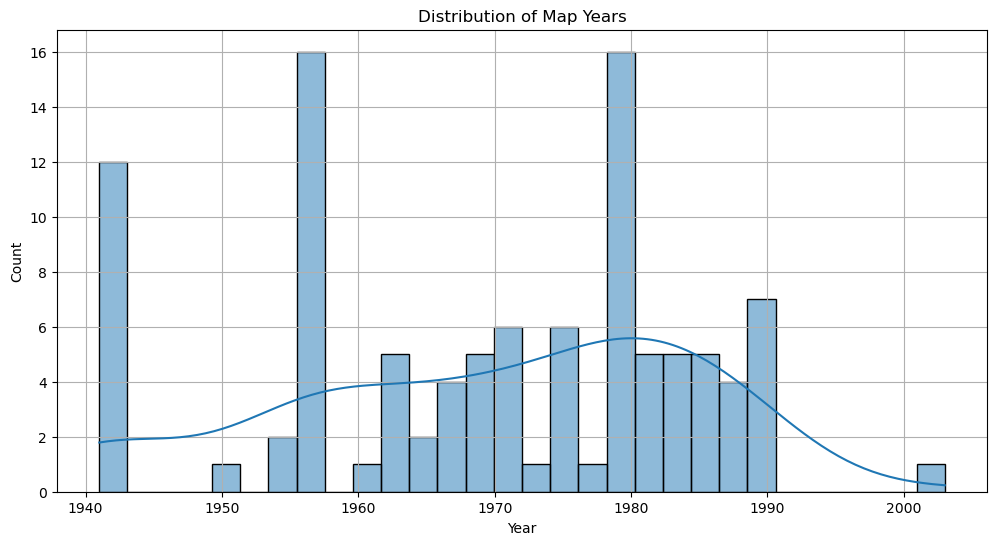

In [5]:
# plot distribution of years (histogram)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
# pass the series as the x parameter (and drop NA values)
sns.histplot(x=df_all_map_meta['year'].dropna().to_numpy(), bins=30, kde=True)
plt.title('Distribution of Map Years')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid()
plt.show()

In [6]:
import re
import pandas as pd
import numpy as np

# Test the fill_missing_metadata function
df_all_map_meta_filled = collector.fill_missing_metadata(df_all_map_meta)

# Check before filling
print('Total maps:', len(df_all_map_meta))

print("> Maps with empty 'year':", df_all_map_meta['year'].isna().sum())
print("> Maps with empty 'scale':", df_all_map_meta['scale'].isna().sum())
print("> Maps with empty 'index':", df_all_map_meta['index'].isna().sum())
print("> Maps with empty 'datum':", df_all_map_meta['datum'].isna().sum())

# Check after filling
print('After filling missing metadata:')
print("> Maps with empty 'year':", df_all_map_meta_filled['year'].isna().sum())
print("> Maps with empty 'scale':", df_all_map_meta_filled['scale'].isna().sum())
print("> Maps with empty 'index':", df_all_map_meta_filled['index'].isna().sum())
print("> Maps with empty 'datum':", df_all_map_meta_filled['datum'].isna().sum())

# Convert 'year' to integer
df_all_map_meta_filled['year'] = df_all_map_meta_filled['year'].astype(pd.Int64Dtype())

# Print the updated DataFrame
print(df_all_map_meta_filled.head(100))

# Check if all gif_path path are valid
invalid_gif_paths = df_all_map_meta_filled[~df_all_map_meta_filled['gif_path'].apply(os.path.exists)]

print(f'Number of invalid gif_path paths: {len(invalid_gif_paths)}')
if len(invalid_gif_paths) > 0:
    print(invalid_gif_paths[['gif_path']])

Total maps: 880
> Maps with empty 'year': 775
> Maps with empty 'scale': 775
> Maps with empty 'index': 775
> Maps with empty 'datum': 829
After filling missing metadata:
> Maps with empty 'year': 0
> Maps with empty 'scale': 0
> Maps with empty 'index': 0
> Maps with empty 'datum': 0
                                                                                                                                  map_file                                                                 gif_file  year scale        index             datum            projection                                                                                                              projection_params  image_width  image_height                                                                                                                                                                                                                                                                                            

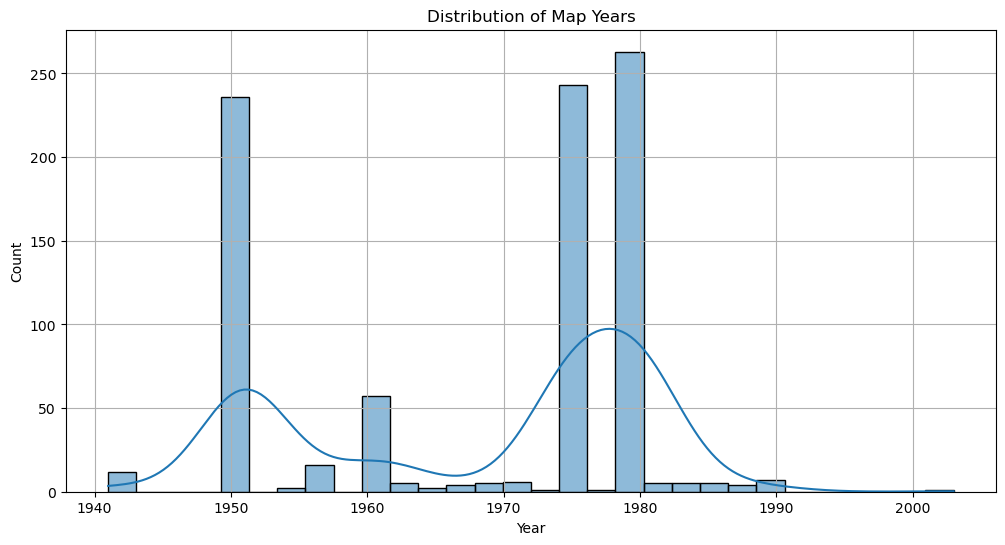

In [7]:
# Replot year distribution
# plot distribution of years (histogram)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.histplot(x=df_all_map_meta_filled['year'].dropna().to_numpy(), bins=30, kde=True)
plt.title('Distribution of Map Years')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid()
plt.show()

In [8]:
# Build unified WGS84 footprints from corners and preview
from importlib import reload
import utils.crs_normalizer as crsn
reload(crsn)
from utils.crs_normalizer import normalize_footprints

# Use filled metadata if available, else the original
df_src = df_all_map_meta_filled if 'df_all_map_meta_filled' in globals() else df_all_map_meta

footprints_wgs84 = normalize_footprints(df_src, datum_col='datum', corners_col='corners', target='EPSG:4326')
print(footprints_wgs84.head())
print(footprints_wgs84.crs)

# Save to GeoPackage next to the metadata CSV
out_gpkg = os.path.join(base_dir, 'map_footprints_wgs84.gpkg')
footprints_wgs84.to_file(out_gpkg, layer='footprints', driver='GPKG')
print(f"Saved WGS84 footprints to {out_gpkg}")


                                                                                                                    map_file                                                            gif_file  year scale   index   datum            projection                                                                                                             projection_params  image_width  image_height                                                                                                                                                                                                                                                                                                                                                                                                                                                control_points                                                                                                                                                               